In [1]:
import pandas as pd
import numpy as np
import matplotlib_inline as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Matplolib/titanic.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

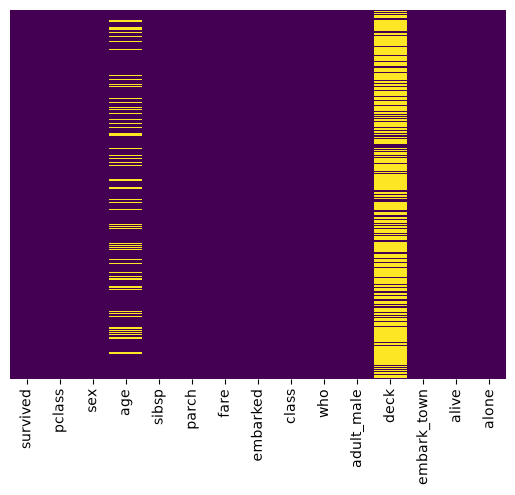

In [4]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [5]:
df.notnull().mean()

survived       1.000000
pclass         1.000000
sex            1.000000
age            0.801347
sibsp          1.000000
parch          1.000000
fare           1.000000
embarked       0.997755
class          1.000000
who            1.000000
adult_male     1.000000
deck           0.227834
embark_town    0.997755
alive          1.000000
alone          1.000000
dtype: float64

# handline the NAN

In [6]:
df.deck.unique()

<StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Length: 8, dtype: str

# Graphs


<Axes: xlabel='survived', ylabel='count'>

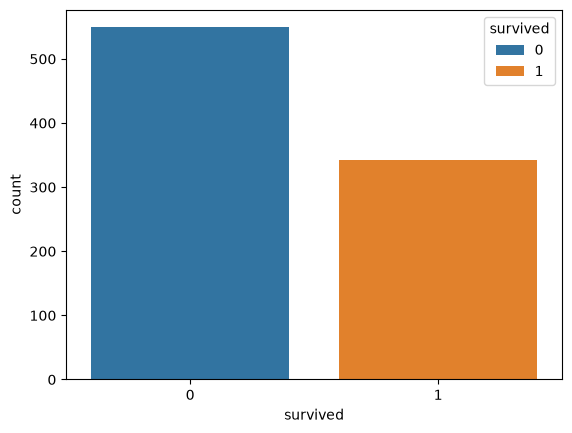

In [7]:
sns.countplot(x='survived',data=df,hue='survived')

<Axes: xlabel='survived', ylabel='count'>

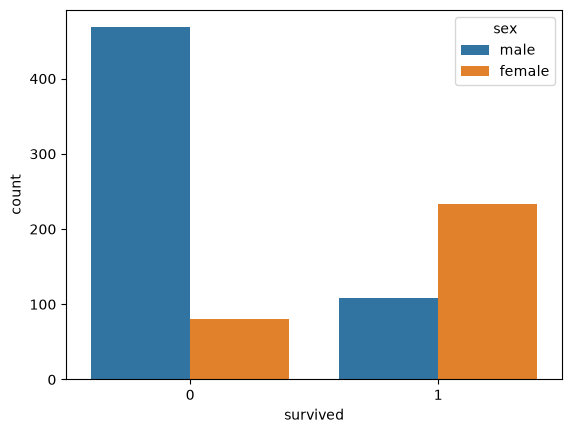

In [8]:
sns.countplot(x='survived',data=df,hue='sex')

<Axes: xlabel='survived', ylabel='count'>

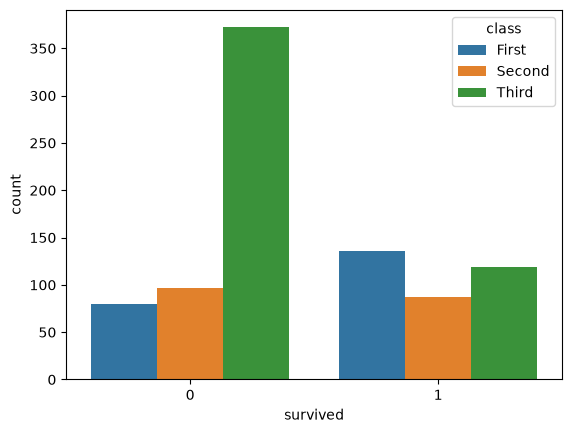

In [9]:
sns.countplot(x='survived',data=df,hue='class',hue_order=["First","Second","Third"])

<Axes: xlabel='sex', ylabel='count'>

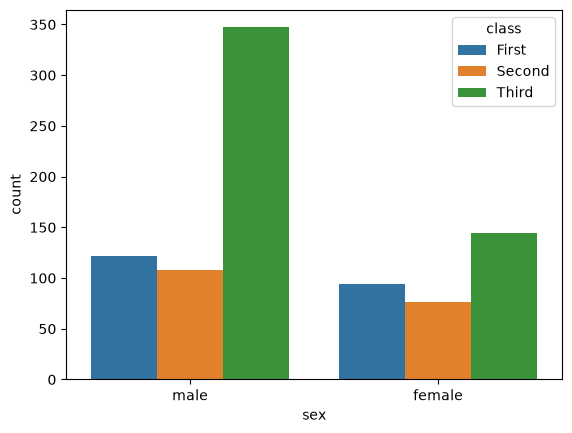

In [10]:
sns.countplot(x='sex',data=df,hue='class',hue_order=["First","Second","Third"])

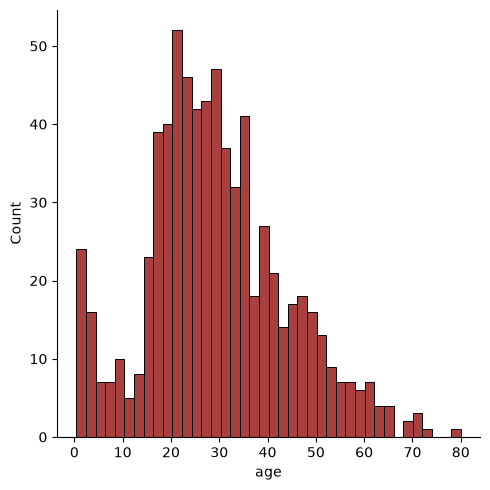

In [11]:
sns.displot(df['age'].dropna(),kde=False,color='darkred',bins=40)

In [12]:
len(df.age.dropna().unique())

88

<Axes: xlabel='class', ylabel='age'>

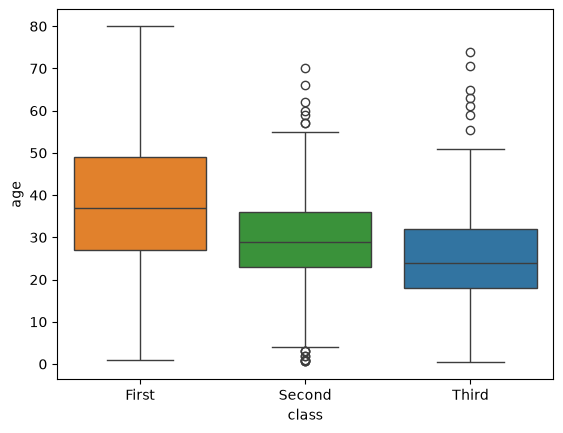

In [13]:
sns.boxplot(x='class',y='age',data=df[df['age'].notnull()],hue='class',order=["First","Second","Third"])

<Axes: xlabel='sex', ylabel='age'>

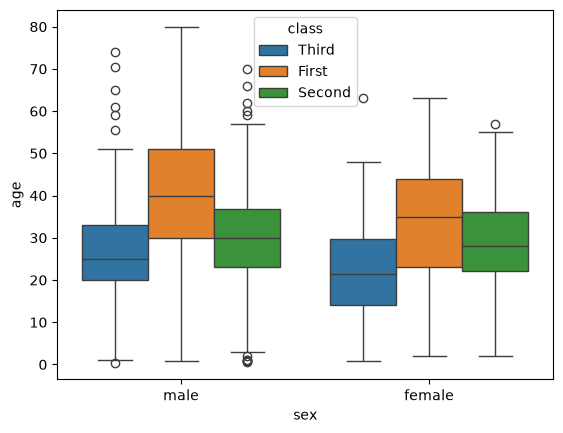

In [14]:
sns.boxplot(x='sex',y='age',data=df[df['age'].notnull()],hue='class')

In [15]:
df_ageNL=df[df['age'].notnull()]




In [16]:
df_ageNL.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: >

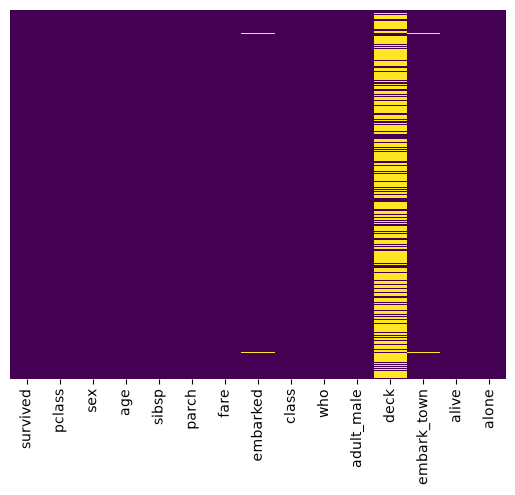

In [17]:
sns.heatmap(data=df_ageNL.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [23]:
answer=df_ageNL.groupby(['sex','class'])['age'].mean()


In [24]:

answer

sex     class 
female  First     34.611765
        Second    28.722973
        Third     21.750000
male    First     41.281386
        Second    30.740707
        Third     26.507589
Name: age, dtype: float64

In [32]:
answer['female']

class
First     34.611765
Second    28.722973
Third     21.750000
Name: age, dtype: float64

In [33]:
answer1=df_ageNL.groupby(['sex','class']).mean(numeric_only=True)
answer1

survived  pclass        age     sibsp     parch        fare  \
sex    class                                                                 
female First   0.964706     1.0  34.611765  0.541176  0.494118  107.946275   
       Second  0.918919     2.0  28.722973  0.500000  0.621622   21.951070   
       Third   0.460784     3.0  21.750000  0.823529  0.950980   15.875369   
male   First   0.396040     1.0  41.281386  0.376238  0.336634   71.142781   
       Second  0.151515     2.0  30.740707  0.373737  0.242424   21.113131   
       Third   0.150198     3.0  26.507589  0.490119  0.256917   12.162695   

               adult_male     alone  
sex    class                         
female First     0.000000  0.376471  
       Second    0.000000  0.405405  
       Third     0.000000  0.372549  
male   First     0.970297  0.534653  
       Second    0.909091  0.636364  
       Third     0.889328  0.739130

In [34]:
answer1['survived']['female', 'First']

np.float64(0.9647058823529412)